In [1]:
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = "/content/drive/MyDrive/NN Multihead 2025/DatasetMTH_coeffs.csv"

Mounted at /content/drive


In [2]:
import os, random, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================

VAR_COLS = [f"var{i}" for i in range(1, 11)]
FCR_COL  = "Fcr"
L1_COL   = "L1"
L2_COL   = "L2"

# W grid for curve reconstruction (fixed, not an input)
Nw = 50
W_GRID = np.linspace(0.0, 1.0, Nw).astype(np.float32)

# Model
ENC = [128,128]       # encoder widths; zdim = last element
ACT = "relu"          # NOTE: lower-case for get_act
DROPOUT = 0.0
BATCHNORM = False

# Training
EPOCHS = 200
BATCH_SIZE = 256
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Loss weights (multitask)
LAMBDA_FCR   = 1.0
LAMBDA_SHAPE = 1.0
USE_CURVE_LOSS = False
LAMBDA_CURVE = 1.0

# Scheduler / Early stop
LR_FACTOR = 0.5
LR_PATIENCE = 4
LR_MIN = 1e-6

ES_PATIENCE = 8
ES_MIN_DELTA = 1e-5
VERBOSE_EVERY = 1

# Mixed precision (AMP)
USE_AMP = True

# =========================
# UTILS
# =========================
def seed_everything(seed=42, deterministic=False):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        try:
            torch.use_deterministic_algorithms(False)
        except Exception:
            pass

def get_act(name: str):
    name = name.lower()
    table = {
        "relu": nn.ReLU(),
        "gelu": nn.GELU(),
        "silu": nn.SiLU(),
        "tanh": nn.Tanh(),
    }
    if name not in table:
        raise ValueError(f"Unsupported activation: {name}. Choose from {list(table.keys())}")
    return table[name]

def mlp(in_dim, widths, out_dim, act="silu", dropout=0.0, batchnorm=False):
    a = get_act(act)
    layers, d = [], in_dim
    for w in widths:
        layers.append(nn.Linear(d, w))
        if batchnorm:
            layers.append(nn.BatchNorm1d(w))
        layers.append(a)
        if dropout and dropout > 0:
            layers.append(nn.Dropout(dropout))
        d = w
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

@torch.no_grad()
def measure_inference_time(model, input_dim=10, device="cpu", batch_size=1,
                           n_warmup=50, n_iters=200, use_amp=True):
    """
    Forward-only inference time for: model(x) -> (fcr, shp, curve).
    Returns (ms_per_batch, ms_per_sample, samples_per_second).
    """
    model.eval()
    is_cuda = device.startswith("cuda")
    amp_on = (use_amp and is_cuda)

    xb = torch.randn(batch_size, input_dim, device=device)

    # warmup
    for _ in range(n_warmup):
        with torch.cuda.amp.autocast(enabled=amp_on):
            _ = model(xb)
    if is_cuda:
        torch.cuda.synchronize()

    # timed
    t0 = time.perf_counter()
    for _ in range(n_iters):
        with torch.cuda.amp.autocast(enabled=amp_on):
            _ = model(xb)
    if is_cuda:
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total_s = t1 - t0
    ms_per_batch = (total_s / n_iters) * 1e3
    ms_per_sample = ms_per_batch / batch_size
    samples_per_s = (batch_size * n_iters) / total_s
    return ms_per_batch, ms_per_sample, samples_per_s

# =========================
# MODEL: Level + Shape (no redundancy)
# =========================
class LevelShapeParabolaNet(nn.Module):
    """
    Shared encoder: X(10) -> z
    Head A: z -> Fcr (scalar)  [level term, equals L0]
    Head B: z -> (L1, L2)      [shape-only]
    Hard constraint: L0 := Fcr
    Curve: lam_hat(W) = Fcr + L1*W + L2*W^2 using fixed basis Phi
    """
    def __init__(self, enc, W_grid, act="silu", dropout=0.0, batchnorm=False):
        super().__init__()
        assert len(enc) >= 1
        zdim = enc[-1]
        enc_hidden = enc[:-1]

        self.encoder  = mlp(10, enc_hidden, zdim, act=act, dropout=dropout, batchnorm=batchnorm)
        self.head_fcr = nn.Linear(zdim, 1)
        self.head_shp = nn.Linear(zdim, 2)

        W = torch.as_tensor(W_grid, dtype=torch.float32)
        Phi = torch.stack([torch.ones_like(W), W, W**2], dim=0)  # (3, Nw)
        self.register_buffer("Phi", Phi)

    def forward(self, x):
        z = self.encoder(x)
        z = torch.relu(z)
        fcr = self.head_fcr(z)      # (B,1)
        shp = self.head_shp(z)      # (B,2) => (L1,L2)

        L0 = fcr
        L1 = shp[:, 0:1]
        L2 = shp[:, 1:2]
        L  = torch.cat([L0, L1, L2], dim=1)     # (B,3)

        curve = L @ self.Phi                    # (B,Nw)
        return fcr, shp, curve

# =========================
# DATASET / LOADER
# =========================
class MultiTaskDataset(Dataset):
    def __init__(self, X, Fcr, Lshape):
        self.X = torch.tensor(X, dtype=torch.float32)                      # (N,10)
        self.F = torch.tensor(Fcr, dtype=torch.float32).reshape(-1, 1)     # (N,1)
        self.S = torch.tensor(Lshape, dtype=torch.float32)                 # (N,2)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.F[i], self.S[i]

def make_loader(X, Fcr, Lshape, bs, shuffle, pin_memory):
    return DataLoader(
        MultiTaskDataset(X, Fcr, Lshape),
        batch_size=bs,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=pin_memory
    )

# =========================
# TRAIN / EVAL
# =========================
def fit(model, dl_tr, dl_va, device="cpu"):
    model.to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    mse = nn.MSELoss()
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.startswith("cuda")))
    best, best_state, bad = float("inf"), None, 0
    t0 = time.perf_counter()

    history = {
        "epoch": [],
        "lr": [],
        "tr_total": [], "va_total": [],
        "tr_fcr": [],   "va_fcr":   [],
        "tr_shp": [],   "va_shp":   [],
        "tr_cur": [],   "va_cur":   [],
    }

    for ep in range(1, EPOCHS + 1):
        # ---- train ----
        model.train()
        tr_tot = tr_f = tr_s = tr_c = 0.0
        ntr = 0

        for xb, fb, sb in dl_tr:
            xb, fb, sb = xb.to(device), fb.to(device), sb.to(device)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(USE_AMP and device.startswith("cuda"))):
                fcr_p, shp_p, curve_p = model(xb)
                loss_f = mse(fcr_p, fb)
                loss_s = mse(shp_p, sb)

                if USE_CURVE_LOSS:
                    L_true = torch.cat([fb, sb[:, 0:1], sb[:, 1:2]], dim=1)  # (B,3)
                    curve_true = L_true @ model.Phi
                    loss_c = mse(curve_p, curve_true)
                else:
                    loss_c = 0.0

                loss = LAMBDA_FCR * loss_f + LAMBDA_SHAPE * loss_s + (LAMBDA_CURVE * loss_c if USE_CURVE_LOSS else 0.0)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = xb.size(0)
            tr_tot += float(loss) * bs
            tr_f   += float(loss_f) * bs
            tr_s   += float(loss_s) * bs
            tr_c   += (float(loss_c) * bs) if USE_CURVE_LOSS else 0.0
            ntr += bs

        tr_total = tr_tot / ntr
        tr_f_m   = tr_f   / ntr
        tr_s_m   = tr_s   / ntr
        tr_c_m   = tr_c   / ntr if USE_CURVE_LOSS else 0.0

        # ---- val ----
        model.eval()
        va_tot = va_f = va_s = va_c = 0.0
        nva = 0
        with torch.no_grad():
            for xb, fb, sb in dl_va:
                xb, fb, sb = xb.to(device), fb.to(device), sb.to(device)
                fcr_p, shp_p, curve_p = model(xb)

                loss_f = mse(fcr_p, fb)
                loss_s = mse(shp_p, sb)

                if USE_CURVE_LOSS:
                    L_true = torch.cat([fb, sb[:, 0:1], sb[:, 1:2]], dim=1)
                    curve_true = L_true @ model.Phi
                    loss_c = mse(curve_p, curve_true)
                else:
                    loss_c = 0.0

                loss = LAMBDA_FCR * loss_f + LAMBDA_SHAPE * loss_s + (LAMBDA_CURVE * loss_c if USE_CURVE_LOSS else 0.0)

                bs = xb.size(0)
                va_tot += float(loss) * bs
                va_f   += float(loss_f) * bs
                va_s   += float(loss_s) * bs
                va_c   += (float(loss_c) * bs) if USE_CURVE_LOSS else 0.0
                nva += bs

        va_total = va_tot / nva
        va_f_m   = va_f   / nva
        va_s_m   = va_s   / nva
        va_c_m   = va_c   / nva if USE_CURVE_LOSS else 0.0

        sch.step(va_total)
        cur_lr = opt.param_groups[0]["lr"]

        improved = (best - va_total) > ES_MIN_DELTA
        if improved:
            best = va_total
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        history["epoch"].append(ep)
        history["lr"].append(cur_lr)
        history["tr_total"].append(tr_total); history["va_total"].append(va_total)
        history["tr_fcr"].append(tr_f_m);     history["va_fcr"].append(va_f_m)
        history["tr_shp"].append(tr_s_m);     history["va_shp"].append(va_s_m)
        history["tr_cur"].append(tr_c_m);     history["va_cur"].append(va_c_m)

        if VERBOSE_EVERY and (ep == 1 or ep % VERBOSE_EVERY == 0):
            print(
                f"Ep {ep:03d} | "
                f"tr={tr_total:.6f} (fcr={tr_f_m:.6f}, shp={tr_s_m:.6f}" + (f", cur={tr_c_m:.6f}" if USE_CURVE_LOSS else "") + ") | "
                f"va={va_total:.6f} (fcr={va_f_m:.6f}, shp={va_s_m:.6f}" + (f", cur={va_c_m:.6f}" if USE_CURVE_LOSS else "") + ") | "
                f"lr={cur_lr:.2e} | best={best:.6f} | bad={bad}/{ES_PATIENCE}"
            )

        if bad >= ES_PATIENCE:
            print(f"Early stop @ ep {ep}, best val_total={best:.6f}")
            break

    ttrain = time.perf_counter() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, ttrain, history

@torch.no_grad()
def eval_original_scale(model, dl, scF: StandardScaler, scS: StandardScaler, device="cpu"):
    model.eval()
    f_pred_s, f_true_s = [], []
    s_pred_s, s_true_s = [], []

    for xb, fb, sb in dl:
        xb = xb.to(device)
        fb = fb.to(device)
        sb = sb.to(device)

        fcr_p_s, shp_p_s, _ = model(xb)  # scaled outputs
        f_pred_s.append(fcr_p_s.cpu().numpy())
        f_true_s.append(fb.cpu().numpy())
        s_pred_s.append(shp_p_s.cpu().numpy())
        s_true_s.append(sb.cpu().numpy())

    f_pred_s = np.vstack(f_pred_s); f_true_s = np.vstack(f_true_s)
    s_pred_s = np.vstack(s_pred_s); s_true_s = np.vstack(s_true_s)

    f_pred = scF.inverse_transform(f_pred_s).reshape(-1, 1)
    f_true = scF.inverse_transform(f_true_s).reshape(-1, 1)

    s_pred = scS.inverse_transform(s_pred_s)
    s_true = scS.inverse_transform(s_true_s)

    rmse_f = float(np.sqrt(np.mean((f_pred - f_true) ** 2)))
    rmse_s = float(np.sqrt(np.mean((s_pred - s_true) ** 2)))

    W = W_GRID.reshape(1, -1)  # (1,Nw)
    curve_pred = f_pred + s_pred[:, 0:1] * W + s_pred[:, 1:2] * (W**2)
    curve_true = f_true + s_true[:, 0:1] * W + s_true[:, 1:2] * (W**2)
    rmse_curve = float(np.sqrt(np.mean((curve_pred - curve_true) ** 2)))

    return rmse_f, rmse_s, rmse_curve

# =========================
# RUN
# =========================
seed_everything(42, deterministic=False)

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

# Inputs
X = df[VAR_COLS].values.astype(np.float32)

# Outputs
Fcr = df[FCR_COL].astype(np.float32).values.reshape(-1, 1)
L1  = df[L1_COL].astype(np.float32).values.reshape(-1, 1)
L2  = df[L2_COL].astype(np.float32).values.reshape(-1, 1)
Lshape = np.concatenate([L1, L2], axis=1)

# split: train/test then train/val
X_tr, X_te, F_tr, F_te, S_tr, S_te = train_test_split(X, Fcr, Lshape, test_size=0.2, random_state=42)
X_tr, X_va, F_tr, F_va, S_tr, S_va = train_test_split(X_tr, F_tr, S_tr, test_size=0.1, random_state=42)

# scale train-only (separate scalers)
scX, scF, scS = StandardScaler(), StandardScaler(), StandardScaler()
X_tr_s = scX.fit_transform(X_tr); X_va_s = scX.transform(X_va); X_te_s = scX.transform(X_te)
F_tr_s = scF.fit_transform(F_tr); F_va_s = scF.transform(F_va); F_te_s = scF.transform(F_te)
S_tr_s = scS.fit_transform(S_tr); S_va_s = scS.transform(S_va); S_te_s = scS.transform(S_te)

device = "cuda" if torch.cuda.is_available() else "cpu"
pin_memory = device.startswith("cuda")

dl_tr = make_loader(X_tr_s, F_tr_s, S_tr_s, BATCH_SIZE, shuffle=True,  pin_memory=pin_memory)
dl_va = make_loader(X_va_s, F_va_s, S_va_s, BATCH_SIZE, shuffle=False, pin_memory=pin_memory)
dl_te = make_loader(X_te_s, F_te_s, S_te_s, BATCH_SIZE, shuffle=False, pin_memory=pin_memory)

model = LevelShapeParabolaNet(ENC, W_grid=W_GRID, act=ACT, dropout=DROPOUT, batchnorm=BATCHNORM).to(device)
p_all, p_tr = count_params(model)

print(f"Params: total={p_all:,} | trainable={p_tr:,} | device={device}")
print(f"n_train={len(X_tr_s):,} | n_val={len(X_va_s):,} | n_test={len(X_te_s):,}")
print(f"Loss weights: fcr={LAMBDA_FCR}, shape={LAMBDA_SHAPE}, curve={LAMBDA_CURVE} (USE_CURVE_LOSS={USE_CURVE_LOSS})")
print("Model: X->z; z->Fcr; z->(L1,L2); L0:=Fcr; curve=Fcr+L1*W+L2*W^2")

model, ttrain, history = fit(model, dl_tr, dl_va, device=device)

rmse_f_val, rmse_s_val, rmse_c_val = eval_original_scale(model, dl_va, scF, scS, device=device)
rmse_f_te,  rmse_s_te,  rmse_c_te  = eval_original_scale(model, dl_te, scF, scS, device=device)

print(f"Train time: {ttrain:.3f}s")
print(f"VAL : RMSE_Fcr={rmse_f_val:.6f} | RMSE_(L1,L2)={rmse_s_val:.6f} | RMSE_Curve50={rmse_c_val:.6f}")
print(f"TEST: RMSE_Fcr={rmse_f_te :.6f} | RMSE_(L1,L2)={rmse_s_te :.6f} | RMSE_Curve50={rmse_c_te :.6f}")

@torch.no_grad()
def predict_time_full_test(model, dl, device="cpu", use_amp=False, n_warmup_batches=5):
    model.eval()
    is_cuda = str(device).startswith("cuda")
    amp_on = (use_amp and is_cuda)

    # warmup
    it = iter(dl)
    for _ in range(n_warmup_batches):
        try:
            batch = next(it)
        except StopIteration:
            break
        xb = batch[0].to(device, non_blocking=True)  # batch[0] luôn là X
        if amp_on:
            with torch.cuda.amp.autocast(True):
                _ = model(xb)
        else:
            _ = model(xb)
    if is_cuda:
        torch.cuda.synchronize()

    # timed full pass
    n = 0
    t0 = time.perf_counter()
    for batch in dl:
        xb = batch[0].to(device, non_blocking=True)
        n += xb.size(0)
        if amp_on:
            with torch.cuda.amp.autocast(True):
                _ = model(xb)
        else:
            _ = model(xb)
    if is_cuda:
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    total_s = t1 - t0
    ms_per_sample = (total_s / max(n,1)) * 1e3
    sps = n / max(total_s, 1e-12)
    return total_s, ms_per_sample, sps, n

total_s, ms_s, sps, n = predict_time_full_test(model, dl_te, device=device, use_amp=False, n_warmup_batches=5)
print(f"FULL TEST predict time (forward-only): total={total_s:.4f}s | {ms_s:.6f} ms/sample | {sps:.1f} samples/s | n={n:,} | device={device}")




Params: total=18,307 | trainable=18,307 | device=cpu
n_train=377,487 | n_val=41,943 | n_test=104,858
Loss weights: fcr=1.0, shape=1.0, curve=1.0 (USE_CURVE_LOSS=False)
Model: X->z; z->Fcr; z->(L1,L2); L0:=Fcr; curve=Fcr+L1*W+L2*W^2


/tmp/ipython-input-2796017840.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and device.startswith("cuda")))
/tmp/ipython-input-2796017840.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and device.startswith("cuda"))):
/tmp/ipython-input-2796017840.py:266: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tr_tot += float(loss) * bs


Ep 001 | tr=0.064395 (fcr=0.024890, shp=0.039505) | va=0.003940 (fcr=0.001887, shp=0.002054) | lr=1.00e-03 | best=0.003940 | bad=0/8
Ep 002 | tr=0.002261 (fcr=0.001189, shp=0.001072) | va=0.001392 (fcr=0.000688, shp=0.000704) | lr=1.00e-03 | best=0.001392 | bad=0/8
Ep 003 | tr=0.001054 (fcr=0.000591, shp=0.000463) | va=0.001034 (fcr=0.000732, shp=0.000302) | lr=1.00e-03 | best=0.001034 | bad=0/8
Ep 004 | tr=0.000700 (fcr=0.000400, shp=0.000300) | va=0.000550 (fcr=0.000275, shp=0.000275) | lr=1.00e-03 | best=0.000550 | bad=0/8
Ep 005 | tr=0.000477 (fcr=0.000273, shp=0.000204) | va=0.000383 (fcr=0.000204, shp=0.000179) | lr=1.00e-03 | best=0.000383 | bad=0/8
Ep 006 | tr=0.000400 (fcr=0.000222, shp=0.000178) | va=0.000474 (fcr=0.000261, shp=0.000213) | lr=1.00e-03 | best=0.000383 | bad=1/8
Ep 007 | tr=0.000308 (fcr=0.000183, shp=0.000125) | va=0.000239 (fcr=0.000123, shp=0.000117) | lr=1.00e-03 | best=0.000239 | bad=0/8
Ep 008 | tr=0.000244 (fcr=0.000137, shp=0.000108) | va=0.000196 (fcr=

In [ ]:
# =========================
# EXPORT PREDICTIONS FOR FULL DATASET -> CSV + DOWNLOAD
# (giữ đúng thứ tự dòng gốc trong df)
# =========================
import os
import numpy as np
import pandas as pd

# 1) Scale toàn bộ dataset bằng scaler đã fit trên train
X_all_s = scX.transform(X).astype(np.float32)
F_all_s = scF.transform(Fcr).astype(np.float32)
S_all_s = scS.transform(Lshape).astype(np.float32)

# 2) DataLoader cho toàn bộ dataset
pin_memory = device.startswith("cuda")
dl_all = make_loader(X_all_s, F_all_s, S_all_s, bs=4096, shuffle=False, pin_memory=pin_memory)

# 3) Predict (original scale)
f_true, f_pred, s_true, s_pred, curve_true, curve_pred = predict_original_scale(
    model, dl_all, scF, scS, device=device
)

# 4) Build output dataframe (giữ nguyên index của df)
out = pd.DataFrame(index=df.index)

# (tuỳ bạn) copy lại cột input
for c in VAR_COLS:
    out[c] = df[c].values

out["Fcr_true"] = f_true.reshape(-1)
out["Fcr_pred"] = f_pred.reshape(-1)

out["L1_true"]  = s_true[:, 0]
out["L2_true"]  = s_true[:, 1]
out["L1_pred"]  = s_pred[:, 0]
out["L2_pred"]  = s_pred[:, 1]

# (Optional) thêm curve 50 điểm
ADD_CURVE_COLS = True
if ADD_CURVE_COLS:
    for j, w in enumerate(W_GRID):
        out[f"curve_true_w{j:02d}"] = curve_true[:, j]
        out[f"curve_pred_w{j:02d}"] = curve_pred[:, j]

# 5) Save CSV
out_path = "predictions_full_dataset.csv"
out.to_csv(out_path, index=True)  # index=True để giữ id dòng (nếu bạn muốn bỏ thì đổi False)
print("Saved:", os.path.abspath(out_path), "| shape:", out.shape)

# 6) Download (auto-detect)
try:
    # Google Colab
    from google.colab import files
    files.download(out_path)
except Exception:
    try:
        # Jupyter / IPython
        from IPython.display import FileLink, display
        display(FileLink(out_path))
    except Exception:
        print("Download not supported here. File saved at:", os.path.abspath(out_path))


/tmp/ipython-input-3744737850.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"curve_true_w{j:02d}"] = curve_true[:, j]
/tmp/ipython-input-3744737850.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"curve_pred_w{j:02d}"] = curve_pred[:, j]
/tmp/ipython-input-3744737850.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

Saved: /content/predictions_full_dataset.csv | shape: (524288, 116)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

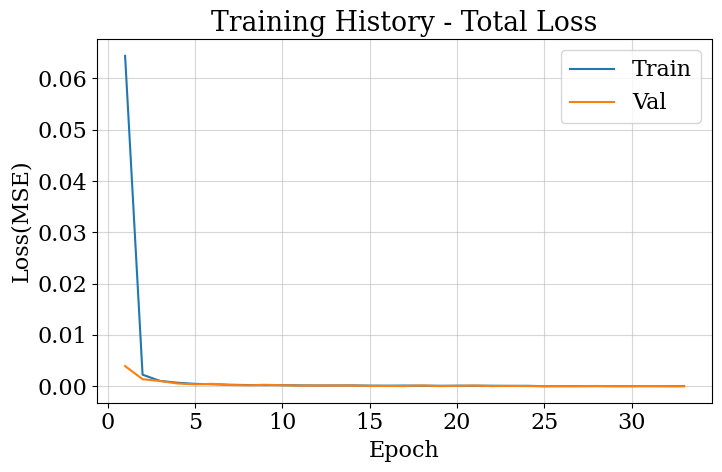

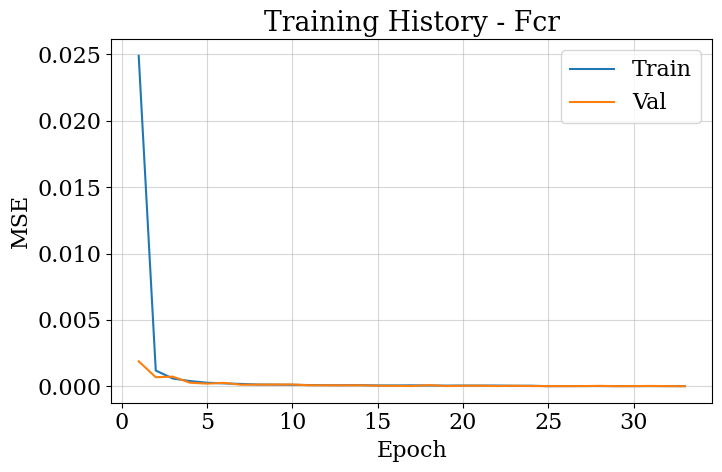

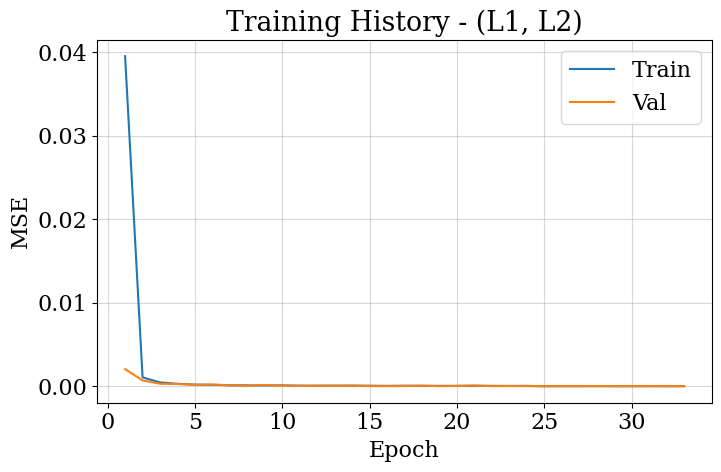

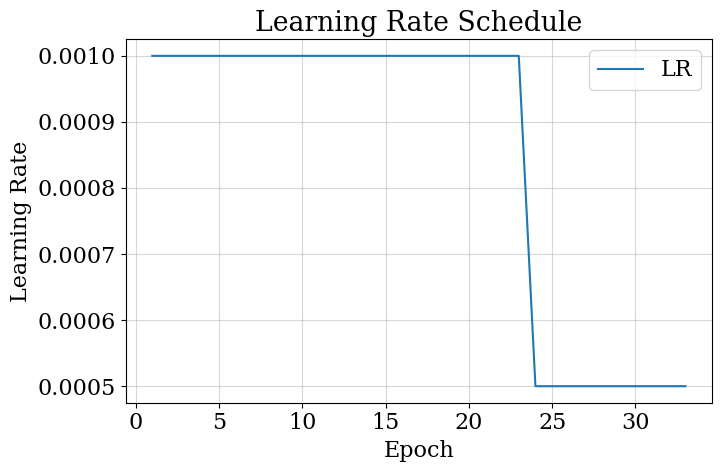

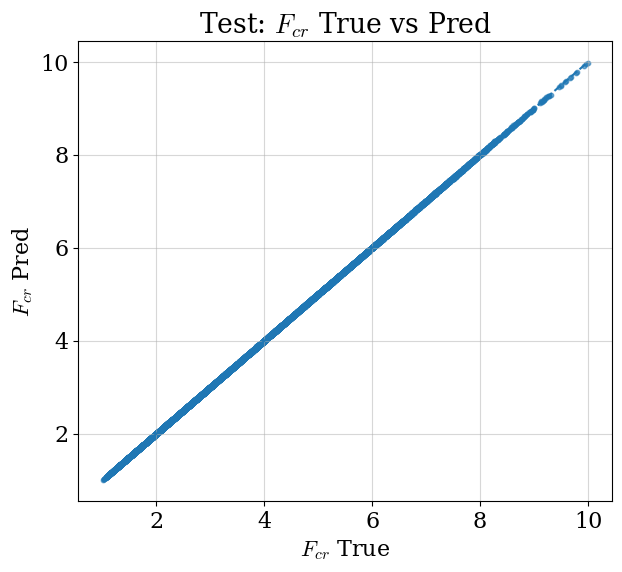

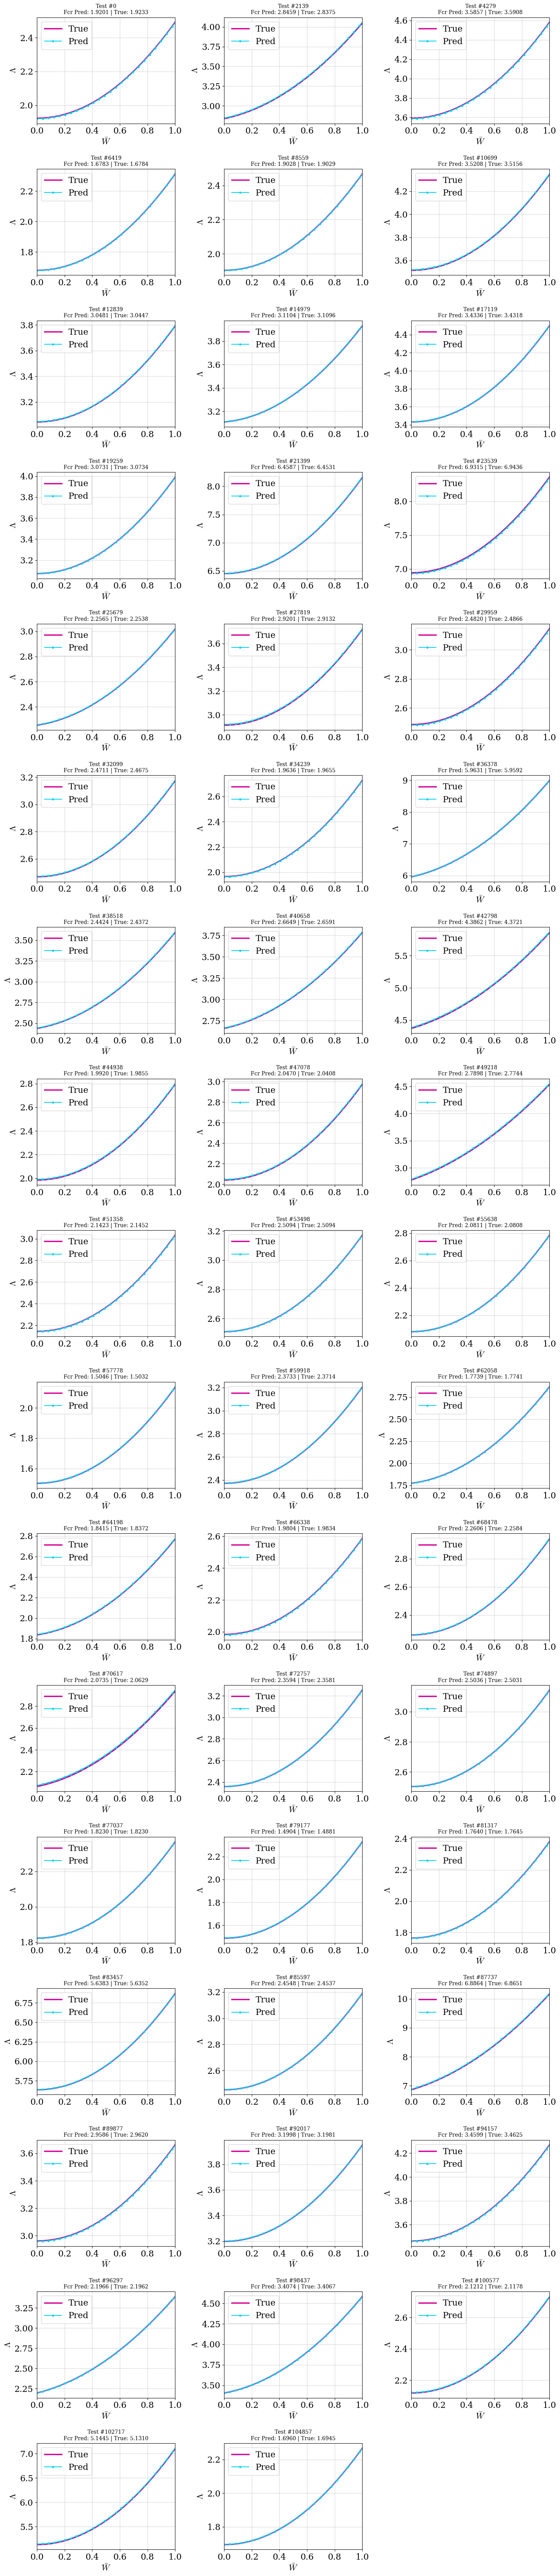

In [3]:
# ================================
# Pretty plots (your style): curves + Fcr True/Pred + training history
# Works with THIS model: LevelShapeParabolaNet (returns fcr, (L1,L2), curve)
# W bar: W_GRID in [0,1]
# ================================
import numpy as np
import matplotlib.pyplot as plt
import torch

def _set_pretty_fonts(use_tex_like_font=True, use_usetex=False, base_fontsize=16):
    if use_tex_like_font:
        plt.rcParams.update({
            "font.family": "serif",
            "mathtext.fontset": "cm",
            "font.size": base_fontsize
        })
    if use_usetex:
        plt.rcParams.update({"text.usetex": True})

@torch.no_grad()
def _predict_batch_original_scale(model, X_scaled, scF, scS, device="cpu"):
    """
    X_scaled: (N,10) scaled by scX already
    Return:
      f_true/pred need external (because in your pipeline dl has fb/sb, but here we may pass arrays)
    Here we only get predictions (scaled -> inverse).
    """
    model.eval()
    X_t = torch.as_tensor(X_scaled, dtype=torch.float32, device=device)
    fcr_s, shp_s, _ = model(X_t)  # scaled outputs

    fcr = scF.inverse_transform(fcr_s.detach().cpu().numpy())  # (N,1)
    shp = scS.inverse_transform(shp_s.detach().cpu().numpy())  # (N,2)
    return fcr, shp

# ================================
# Plot sample curves (your layout)
# ================================
def plot_sample_curves_levelshape(
    model, X_scaled, Fcr_scaled, Lshape_scaled,
    scF, scS, device,
    num_samples=50, title_prefix="Test sample",
    use_tex_like_font=True, use_usetex=False,
    markevery=1,
    xlim=(0.0, 1.0),
    true_color="#DB5BB5",
    pred_color="#00D3EF",
    n_cols=3
):
    """
    model: LevelShapeParabolaNet
    X_scaled: (N,10)
    Fcr_scaled: (N,1) scaled by scF
    Lshape_scaled: (N,2) scaled by scS  (L1,L2)
    """
    _set_pretty_fonts(use_tex_like_font, use_usetex, base_fontsize=16)

    model.eval()
    N = X_scaled.shape[0]
    if N == 0:
        print("No samples to plot.")
        return

    idx_list = np.linspace(0, N - 1, num_samples, dtype=int)

    n_rows = (num_samples + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    # Precompute W once
    W = W_GRID.copy()

    for j, idx in enumerate(idx_list):
        x_i     = X_scaled[idx:idx+1]          # (1,10)
        fcr_i_s = Fcr_scaled[idx:idx+1]        # (1,1)
        shp_i_s = Lshape_scaled[idx:idx+1]     # (1,2)

        X_t = torch.as_tensor(x_i, dtype=torch.float32, device=device)

        with torch.no_grad():
            fcr_pred_s_t, shp_pred_s_t, _ = model(X_t)

        # Inverse scaling (scalar coeffs)
        fcr_true = scF.inverse_transform(fcr_i_s)[0][0]
        fcr_pred = scF.inverse_transform(fcr_pred_s_t.detach().cpu().numpy())[0][0]

        shp_true = scS.inverse_transform(shp_i_s)[0]  # (2,)
        shp_pred = scS.inverse_transform(shp_pred_s_t.detach().cpu().numpy())[0]

        # Build curves in original scale: curve = Fcr + L1*W + L2*W^2
        curve_true = fcr_true + shp_true[0] * W + shp_true[1] * (W**2)
        curve_pred = fcr_pred + shp_pred[0] * W + shp_pred[1] * (W**2)

        ax = fig.add_subplot(n_rows, n_cols, j + 1)

        ax.plot(
            W, curve_true,
            label="True",
            linewidth=2.5,
            color=true_color,
        )
        ax.plot(
            W, curve_pred,
            label="Pred",
            linewidth=1.5,
            linestyle="-",
            color=pred_color,
            marker="o", markersize=3.0, markevery=markevery
        )

        ax.set_title(
            f"{title_prefix} #{idx}\nFcr Pred: {fcr_pred:.4f} | True: {fcr_true:.4f}",
            fontsize=10
        )

        ax.set_xlabel(r"$\bar{W}$")
        ax.set_ylabel(r"$\Lambda$")

        ax.set_xlim(xlim[0], xlim[1])
        ax.set_xticks(np.linspace(xlim[0], xlim[1], 6))

        ax.grid(True, alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

# ================================
# Plot Fcr True vs Pred (pretty)
# ================================
def plot_fcr_true_vs_pred(
    model, X_scaled, Fcr_scaled,
    scF, device,
    title="Fcr True vs Pred",
    use_tex_like_font=True, use_usetex=False,
    point_size=10, alpha=0.6,
    diag_linestyle="--"
):
    _set_pretty_fonts(use_tex_like_font, use_usetex, base_fontsize=16)

    model.eval()
    X_t = torch.as_tensor(X_scaled, dtype=torch.float32, device=device)
    with torch.no_grad():
        fcr_pred_s, _, _ = model(X_t)

    f_true = scF.inverse_transform(Fcr_scaled).reshape(-1)
    f_pred = scF.inverse_transform(fcr_pred_s.detach().cpu().numpy()).reshape(-1)

    plt.figure(figsize=(6.5, 6))
    plt.scatter(f_true, f_pred, s=point_size, alpha=alpha)

    mn = float(min(f_true.min(), f_pred.min()))
    mx = float(max(f_true.max(), f_pred.max()))
    plt.plot([mn, mx], [mn, mx], diag_linestyle, linewidth=1.5)

    plt.xlabel(r"$F_{cr}$ True")
    plt.ylabel(r"$F_{cr}$ Pred")
    plt.title(title)
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

# ================================
# Plot training history (pretty)
# ================================
def plot_training_history_pretty(
    history,
    use_tex_like_font=True, use_usetex=False,
    show_lr=True
):
    _set_pretty_fonts(use_tex_like_font, use_usetex, base_fontsize=16)

    ep = np.array(history["epoch"])

    # Total
    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ep, history["tr_total"], label="Train")
    plt.plot(ep, history["va_total"], label="Val")
    plt.xlabel("Epoch"); plt.ylabel("Loss(MSE)")
    plt.title("Training History - Total Loss")
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Fcr
    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ep, history["tr_fcr"], label="Train")
    plt.plot(ep, history["va_fcr"], label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title("Training History - Fcr")
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Shape
    plt.figure(figsize=(7.5, 5.0))
    plt.plot(ep, history["tr_shp"], label="Train")
    plt.plot(ep, history["va_shp"], label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title("Training History - (L1, L2)")
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Curve (only meaningful if enabled)
    if "tr_cur" in history and any(v != 0.0 for v in history["tr_cur"]) and any(v != 0.0 for v in history["va_cur"]):
        plt.figure(figsize=(7.5, 5.0))
        plt.plot(ep, history["tr_cur"], label="Train")
        plt.plot(ep, history["va_cur"], label="Val")
        plt.xlabel("Epoch"); plt.ylabel("MSE")
        plt.title("Training History - Curve")
        plt.grid(True, alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # LR
    if show_lr and "lr" in history:
        plt.figure(figsize=(7.5, 5.0))
        plt.plot(ep, history["lr"], label="LR")
        plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
        plt.title("Learning Rate Schedule")
        plt.grid(True, alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ================================
# CALL EXAMPLE (after training)
# You already have: model, device, history, and scaled arrays:
#   X_te_s, F_te_s, S_te_s
# ================================
if __name__ == "__main__":
    # 1) Training history
    plot_training_history_pretty(history, use_tex_like_font=True, use_usetex=False, show_lr=True)

    # 2) Fcr scatter (Test)
    plot_fcr_true_vs_pred(
        model,
        X_te_s, F_te_s,
        scF, device,
        title="Test: $F_{cr}$ True vs Pred",
        use_tex_like_font=True, use_usetex=False
    )

    # 3) Sample curves grid (Test)
    plot_sample_curves_levelshape(
        model,
        X_te_s, F_te_s, S_te_s,
        scF, scS,
        device,
        num_samples=50,
        title_prefix="Test",
        markevery=2,
        xlim=(0.0, 1.0),
        true_color="#D50095",
        pred_color="#00D3EF",
        n_cols=3
    )


In [ ]:
!cp predictions_full_dataset.csv "/content/drive/MyDrive/NN Multihead 2025/"

